## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)


## 2. Load the Dataset

In [2]:
df = pd.read_csv("StudentsPerformance.csv")

print("Dataset loaded successfully.")
df.head()


Dataset loaded successfully.


,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


## 3. Data Exploration & Cleaning

In [3]:
print("Dataset Shape:", df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:", df.duplicated().sum())


Dataset Shape: (1000, 8)

Column Names:
['gender', 'race/ethnicity', 'parental level of education', 'lunch', 'test preparation course', 'math score', 'reading score', 'writing score']

Data Types:
gender                         object
race/ethnicity                 object
parental level of education    object
lunch                          object
test preparation course        object
math score                      int64
reading score                   int64
writing score                   int64
dtype: object

Missing Values:
gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64

Duplicate Rows: 0


In [4]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


In [5]:
df.describe().round(2)


,math score,reading score,writing score
count,1000.00,1000.00,1000.00
mean,66.09,69.17,68.05
std,15.16,14.60,15.20
min,0.00,17.00,10.00
25%,57.00,59.00,57.75
50%,66.00,70.00,69.00
75%,77.00,79.00,79.00
max,100.00,100.00,100.00


In [6]:
df.describe(include="object")


,gender,race/ethnicity,parental level of education,lunch,test preparation course
count,1000,1000,1000,1000,1000
unique,2,5,6,2,2
top,female,group C,some college,standard,none
freq,518,319,226,645,642


### 5-Line Dataset Summary

1. The dataset contains 1,000 student records.
2. It contains 8 original columns covering demographics, family background, preparation, and academic performance.
3. Academic performance is measured using math, reading, and writing scores.
4. The dataset contains no missing values and no duplicate rows.
5. The analysis will examine factors associated with scores and identify students who may need additional support.


## 4. Understand the Categorical Variables

In [7]:
for column in df.select_dtypes(include="object").columns:
    print(f"\n{column}:")
    print(df[column].unique())



gender:
['female' 'male']

race/ethnicity:
['group B' 'group C' 'group A' 'group D' 'group E']

parental level of education:
["bachelor's degree" 'some college' "master's degree" "associate's degree"
 'high school' 'some high school']

lunch:
['standard' 'free/reduced']

test preparation course:
['none' 'completed']


## 5. Factor Analysis — Question 1
### Does parental education level affect scores?

In [8]:
parental_scores = (
    df.groupby("parental level of education")[["math score", "reading score", "writing score"]]
      .mean()
      .round(2)
)

parental_scores


,math score,reading score,writing score
parental level of education,,,
associate's degree,67.88,70.93,69.90
bachelor's degree,69.39,73.00,73.38
high school,62.14,64.70,62.45
master's degree,69.75,75.37,75.68
some college,67.13,69.46,68.84
some high school,63.50,66.94,64.89


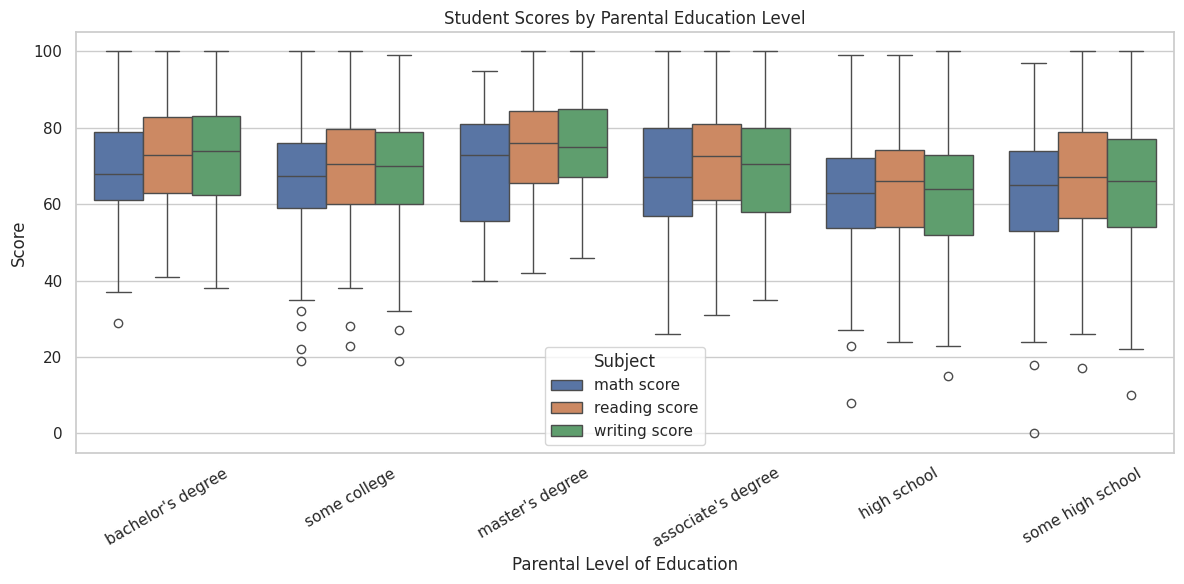

In [9]:
parental_melted = df.melt(
    id_vars="parental level of education",
    value_vars=["math score", "reading score", "writing score"],
    var_name="Subject",
    value_name="Score"
)

plt.figure(figsize=(12, 6))
sns.boxplot(
    data=parental_melted,
    x="parental level of education",
    y="Score",
    hue="Subject"
)
plt.title("Student Scores by Parental Education Level")
plt.xlabel("Parental Level of Education")
plt.ylabel("Score")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


## 6. Factor Analysis — Question 2
### Do students who complete test preparation score higher?

In [10]:
test_prep_scores = (
    df.groupby("test preparation course")[["math score", "reading score", "writing score"]]
      .mean()
      .round(2)
)

test_prep_scores


,math score,reading score,writing score
test preparation course,,,
completed,69.70,73.89,74.42
none,64.08,66.53,64.50


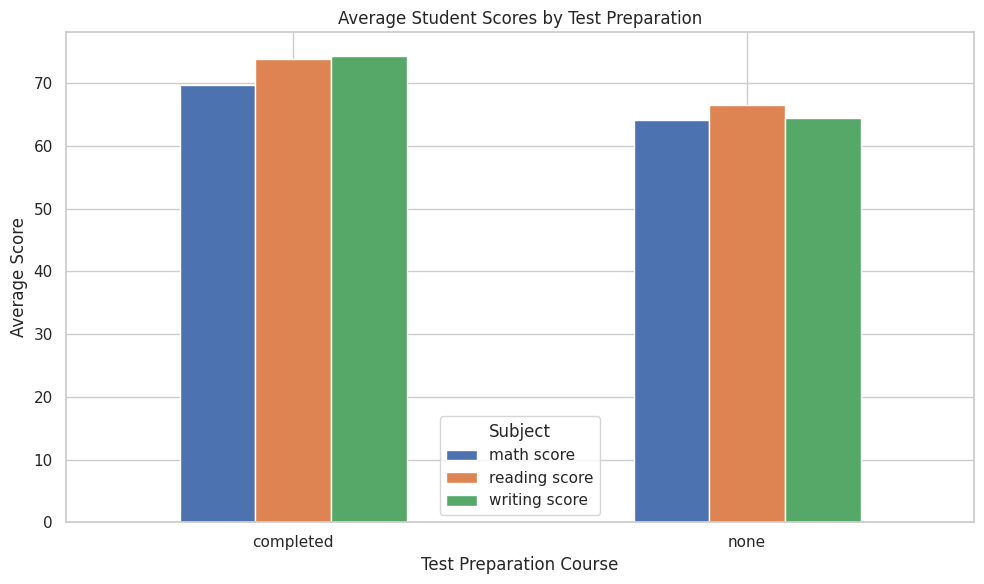

In [11]:
test_prep_scores.plot(kind="bar", figsize=(10, 6))
plt.title("Average Student Scores by Test Preparation")
plt.xlabel("Test Preparation Course")
plt.ylabel("Average Score")
plt.xticks(rotation=0)
plt.legend(title="Subject")
plt.tight_layout()
plt.show()


In [12]:
completed = test_prep_scores.loc["completed"]
none = test_prep_scores.loc["none"]
improvement = (completed - none).round(2)

print("Score improvement for students who completed test preparation:")
print(improvement)


Score improvement for students who completed test preparation:
math score       5.62
reading score    7.36
writing score    9.92
dtype: float64


## 7. Factor Analysis — Question 3
### What is the correlation between reading, writing, and math scores?

In [13]:
score_columns = ["math score", "reading score", "writing score"]
correlation = df[score_columns].corr().round(2)
correlation


,math score,reading score,writing score
math score,1.00,0.82,0.80
reading score,0.82,1.00,0.95
writing score,0.80,0.95,1.00


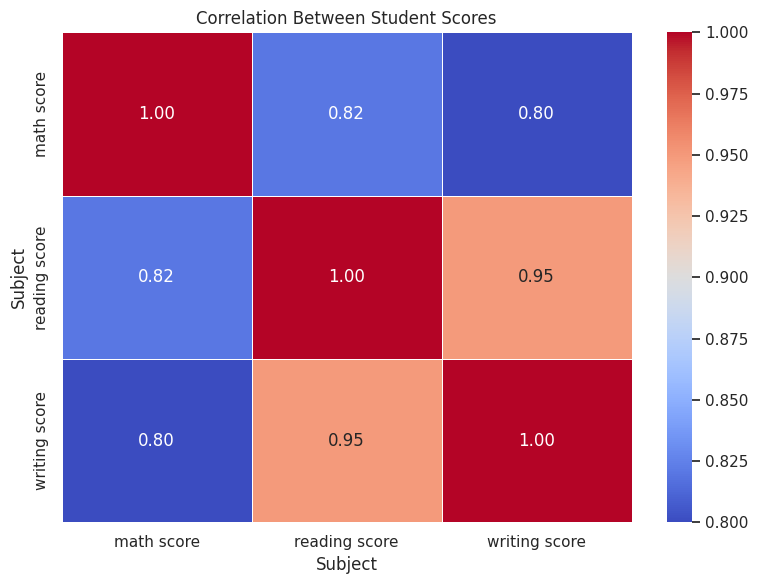

In [14]:
plt.figure(figsize=(8, 6))
sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)
plt.title("Correlation Between Student Scores")
plt.xlabel("Subject")
plt.ylabel("Subject")
plt.tight_layout()
plt.show()


## 8. Factor Analysis — Question 4
### Which gender performs better in which subject?

In [15]:
gender_scores = (
    df.groupby("gender")[["math score", "reading score", "writing score"]]
      .mean()
      .round(2)
)

gender_scores


,math score,reading score,writing score
gender,,,
female,63.63,72.61,72.47
male,68.73,65.47,63.31


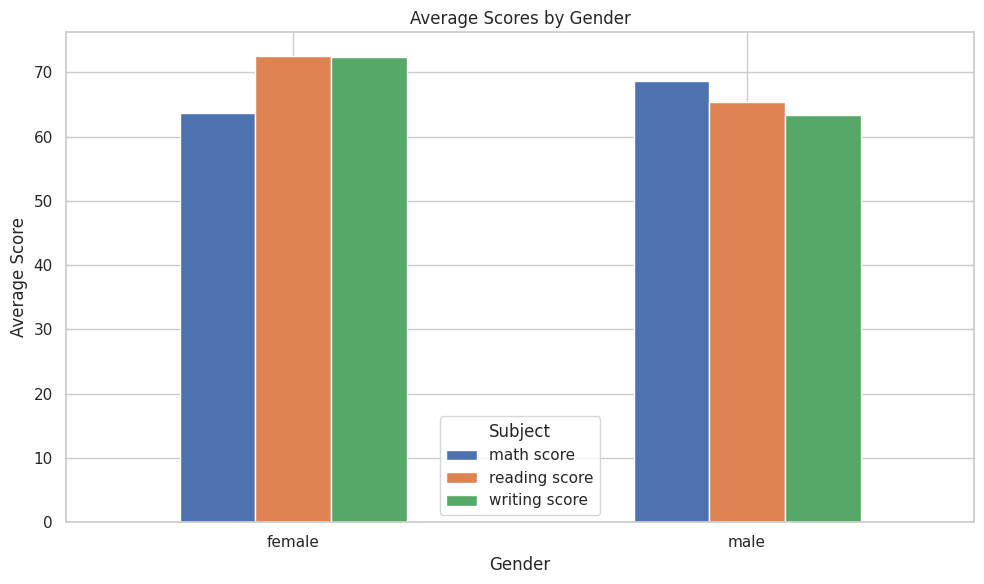

In [16]:
gender_scores.plot(kind="bar", figsize=(10, 6))
plt.title("Average Scores by Gender")
plt.xlabel("Gender")
plt.ylabel("Average Score")
plt.xticks(rotation=0)
plt.legend(title="Subject")
plt.tight_layout()
plt.show()


## 9. Factor Analysis — Question 5
### What is the distribution of total scores?

In [17]:
df["total score"] = df[["math score", "reading score", "writing score"]].sum(axis=1)

df[["math score", "reading score", "writing score", "total score"]].head()


,math score,reading score,writing score,total score
0,72,72,74,218
1,69,90,88,247
2,90,95,93,278
3,47,57,44,148
4,76,78,75,229


In [18]:
df["total score"].describe().round(2)


,total score
count,1000.00
mean,203.31
std,42.77
min,27.00
25%,175.00
50%,205.00
75%,233.00
max,300.00


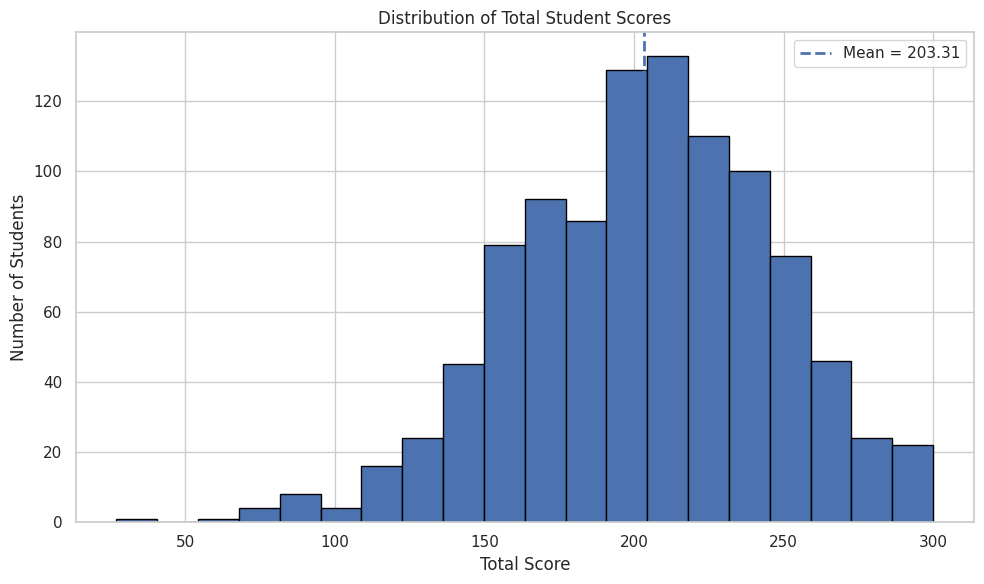

In [19]:
mean_score = df["total score"].mean()

plt.figure(figsize=(10, 6))
plt.hist(df["total score"], bins=20, edgecolor="black")
plt.axvline(
    mean_score,
    linestyle="--",
    linewidth=2,
    label=f"Mean = {mean_score:.2f}"
)
plt.title("Distribution of Total Student Scores")
plt.xlabel("Total Score")
plt.ylabel("Number of Students")
plt.legend()
plt.tight_layout()
plt.show()


## 10. Required Scatter Plot — Reading vs Math

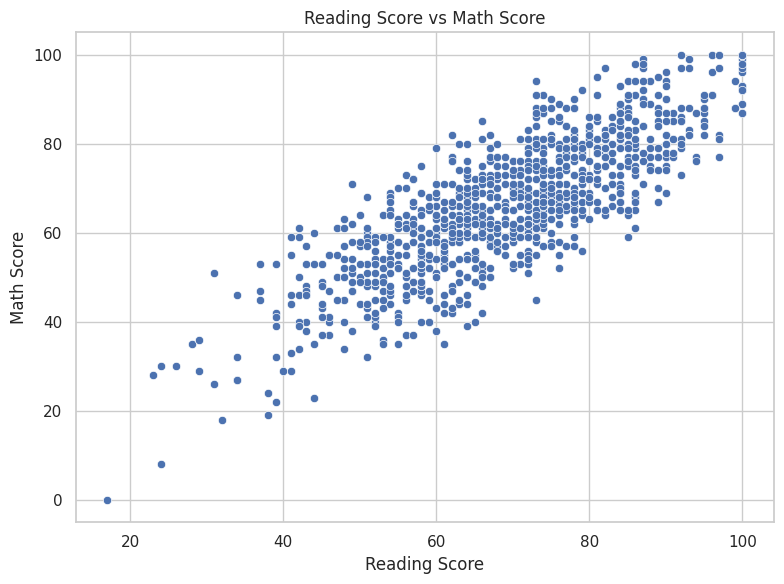

In [20]:
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=df,
    x="reading score",
    y="math score"
)
plt.title("Reading Score vs Math Score")
plt.xlabel("Reading Score")
plt.ylabel("Math Score")
plt.tight_layout()
plt.show()


## 11. At-Risk Student Segmentation

**Definition used:** A student is classified as at-risk if they score below 50 in **any** of the three subjects.


In [21]:
df["at_risk"] = (
    (df["math score"] < 50) |
    (df["reading score"] < 50) |
    (df["writing score"] < 50)
)

risk_counts = df["at_risk"].value_counts()

print("At-Risk Students:", int(risk_counts.get(True, 0)))
print("Not At-Risk Students:", int(risk_counts.get(False, 0)))
print(f"At-Risk Percentage: {df['at_risk'].mean() * 100:.2f}%")


At-Risk Students: 188
Not At-Risk Students: 812
At-Risk Percentage: 18.80%


### At-Risk Percentage by Gender

In [22]:
risk_by_gender = (
    df.groupby("gender")["at_risk"]
      .mean()
      .mul(100)
      .round(2)
      .reset_index(name="At-Risk Percentage")
)

risk_by_gender


,gender,At-Risk Percentage
0,female,17.18
1,male,20.54


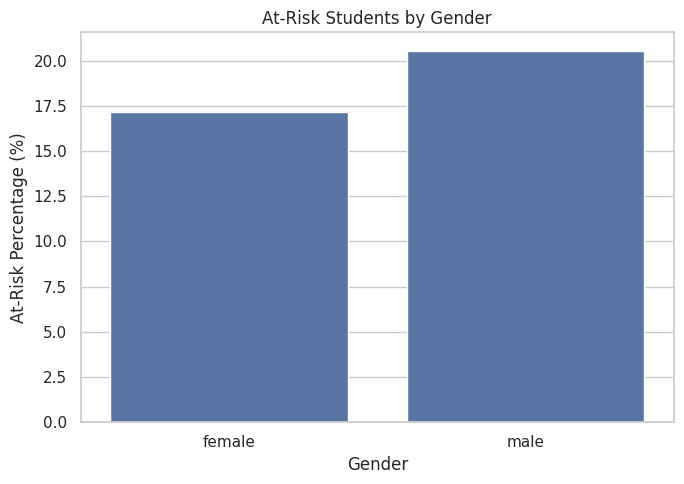

In [23]:
plt.figure(figsize=(7, 5))
sns.barplot(data=risk_by_gender, x="gender", y="At-Risk Percentage")
plt.title("At-Risk Students by Gender")
plt.xlabel("Gender")
plt.ylabel("At-Risk Percentage (%)")
plt.tight_layout()
plt.show()


### At-Risk Percentage by Test Preparation

In [24]:
risk_by_prep = (
    df.groupby("test preparation course")["at_risk"]
      .mean()
      .mul(100)
      .round(2)
      .reset_index(name="At-Risk Percentage")
)

risk_by_prep


,test preparation course,At-Risk Percentage
0,completed,10.06
1,none,23.68


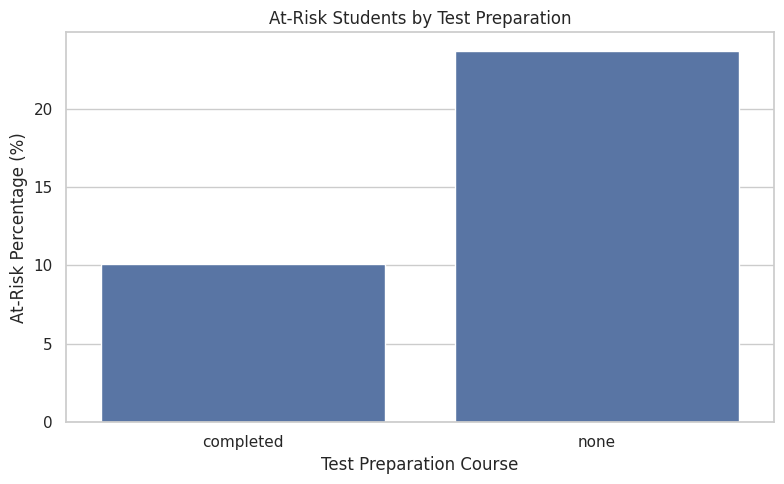

In [25]:
plt.figure(figsize=(8, 5))
sns.barplot(
    data=risk_by_prep,
    x="test preparation course",
    y="At-Risk Percentage"
)
plt.title("At-Risk Students by Test Preparation")
plt.xlabel("Test Preparation Course")
plt.ylabel("At-Risk Percentage (%)")
plt.tight_layout()
plt.show()


### At-Risk Percentage by Parental Education

In [26]:
risk_by_parent_education = (
    df.groupby("parental level of education")["at_risk"]
      .mean()
      .mul(100)
      .round(2)
      .reset_index(name="At-Risk Percentage")
      .sort_values("At-Risk Percentage", ascending=False)
)

risk_by_parent_education


,parental level of education,At-Risk Percentage
5,some high school,25.70
2,high school,25.00
4,some college,16.81
0,associate's degree,14.86
1,bachelor's degree,13.56
3,master's degree,10.17


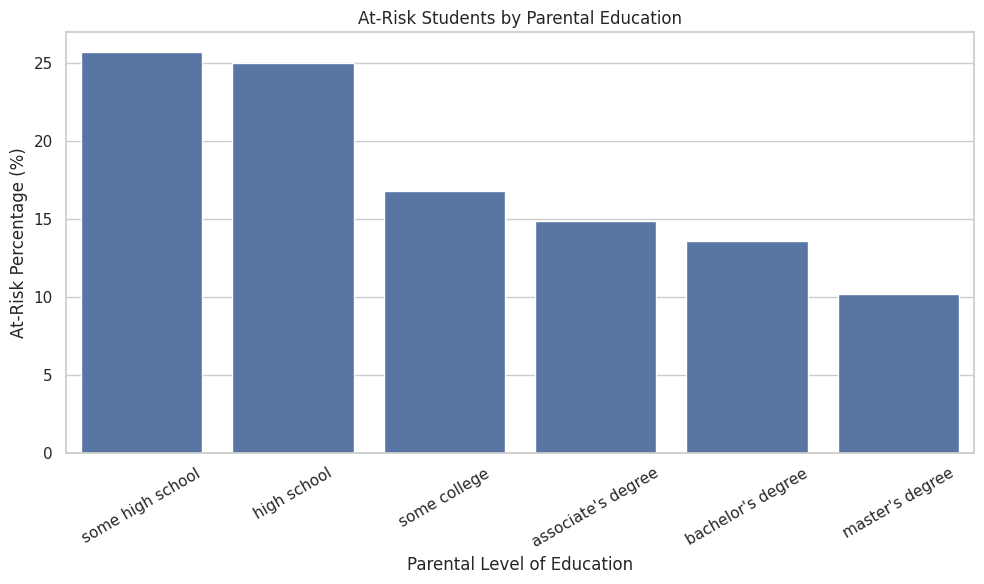

In [27]:
plt.figure(figsize=(10, 6))
sns.barplot(
    data=risk_by_parent_education,
    x="parental level of education",
    y="At-Risk Percentage"
)
plt.title("At-Risk Students by Parental Education")
plt.xlabel("Parental Level of Education")
plt.ylabel("At-Risk Percentage (%)")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


## 12. Final Project Summary

In [28]:
print("PROJECT 02 - STUDENT PERFORMANCE ANALYSIS")
print("=" * 50)
print(f"Total Students: {len(df)}")
print(f"Average Total Score: {df['total score'].mean():.2f}")
print(f"Median Total Score: {df['total score'].median():.2f}")
print(f"At-Risk Students: {int(df['at_risk'].sum())}")
print(f"At-Risk Percentage: {df['at_risk'].mean() * 100:.2f}%")

print("\nTest Preparation At-Risk Rates:")
print(df.groupby("test preparation course")["at_risk"].mean().mul(100).round(2))

print("\nParental Education At-Risk Rates:")
print(
    df.groupby("parental level of education")["at_risk"]
      .mean()
      .mul(100)
      .round(2)
      .sort_values(ascending=False)
)


PROJECT 02 - STUDENT PERFORMANCE ANALYSIS
Total Students: 1000
Average Total Score: 203.31
Median Total Score: 205.00
At-Risk Students: 188
At-Risk Percentage: 18.80%

Test Preparation At-Risk Rates:
test preparation course
completed    10.06
none         23.68
Name: at_risk, dtype: float64

Parental Education At-Risk Rates:
parental level of education
some high school      25.70
high school           25.00
some college          16.81
associate's degree    14.86
bachelor's degree     13.56
master's degree       10.17
Name: at_risk, dtype: float64


# 13. Principal's Report

## Executive Summary

This analysis examines the academic performance of 1,000 students across mathematics, reading, and writing. Students who completed the test preparation course achieved higher average scores in all three subjects than students who did not complete it. Using a threshold of below 50 in any subject, 188 students (18.8%) were identified as at-risk, highlighting the need for targeted academic support.

## 5 Key Findings

1. **Test preparation is associated with higher performance.** Students who completed the test preparation course achieved higher average scores in mathematics (69.70), reading (73.89), and writing (74.42) than students who did not complete the course.

2. **Reading and writing scores have a very strong relationship.** Reading and writing had the strongest correlation at 0.95. Mathematics was also strongly correlated with reading (0.82) and writing (0.80).

3. **Performance differs by gender across subjects.** Male students achieved a higher average mathematics score (68.73 versus 63.63 for females), while female students achieved higher average reading (72.61 versus 65.47) and writing scores (72.47 versus 63.31).

4. **A significant proportion of students are at risk.** Using the below-50-in-any-subject definition, 188 students, or 18.8% of the dataset, were classified as at-risk.

5. **At-risk rates vary by parental education level.** Students whose parents had some high school education had the highest at-risk percentage (25.70%), followed by the high school group (25.00%). The master's-degree group had the lowest at-risk percentage (10.17%). This is an association and does not establish causation.

## 3 Actionable Recommendations

1. **Expand structured test-preparation support.** Provide structured preparation sessions, particularly for students who have not completed preparation. The completed-preparation group had a lower at-risk rate (10.06%) than the group with no preparation (23.68%).

2. **Introduce an early-warning support system.** Identify students who score below 50 in any subject and provide targeted tutoring, regular progress checks, and additional learning support before major examinations.

3. **Strengthen integrated reading and writing activities.** Because reading and writing scores have a very strong correlation (0.95), incorporate reading-comprehension and writing activities into regular classroom instruction and monitor progress in both areas.

## Most Impactful Recommendation

The most impactful recommendation is to expand structured test-preparation support. Students who completed test preparation had higher average scores across all three subjects and a substantially lower at-risk rate than students who did not complete preparation. Making structured preparation available to more students could therefore be a practical way to improve academic outcomes and reduce the number of students requiring intensive intervention.
